# Cross-City Crash Data: Exploratory Data Analysis

**Status:** runs against the curated Parquet produced by the
`crash_pipeline` DAG. Run the DAG first, then run this notebook from
the `notebooks/` folder (Kernel → Restart & Run All).

**Interpretation cells** (marked *Finding*) are written from this
run's outputs. If the data changes, re-run and update them.

**Data source:** the curated layer (`data/curated/fact_crash/`, partitioned by
`source_id/year/month`), not the raw layer. Reading the raw layer
would re-implement the transformation logic that the pipeline exists
to centralize.

## Rule for this notebook: structural nulls are not findings

Several canonical fields are **structurally null for some sources**
because the source does not collect them — this is documented in
`docs/data_dictionary.md` (section "Cross-Source Gaps at a Glance") and
in `docs/data_contract.md` (section 4). Any cross-source comparison
must account for this, or it will read a data gap as a finding.

Concretely: a naive chart of **hit-and-run rate by city** shows 0% for
NYC and UK. That is not evidence NYC and the UK have no hit-and-runs —
it is evidence the source does not record the field. The same applies
to `crash_type` (Chicago only), `primary_cause` (Chicago + NYC only),
`weather_condition` / `lighting_condition` / `posted_speed_limit_mph`
(Chicago + UK only), `num_killed` (Chicago + NYC only), and the
`severity = 'serious'` bucket (Chicago + UK only).

Every cross-source chart in this notebook either (a) filters to the
sources that actually populate the field, or (b) annotates the nulls
as structural in the caption.

## 0. Setup

Imports and a single helper for loading one partition of curated
Parquet. Reading a single partition (`source_id` + year) rather than
the full dataset is the access pattern the pipeline is designed for —
it also exercises the partition-pruning requirement from the project
proposal (section 9).

In [1]:
from pathlib import Path

import pandas as pd
import pyarrow.dataset as ds
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Curated layer written by src/transform/curated.py.
CURATED_ROOT = Path("../data/curated/fact_crash")
SOURCES = ["chicago_us", "nyc_us", "uk_stats19"]

# Only the columns this notebook uses; loading every column of 1.6M rows
# would need several GB of memory.
EDA_COLUMNS = [
    "crash_id", "source_id", "crash_timestamp_utc", "source_local_timezone",
    "severity", "num_injured_total", "num_killed", "has_valid_coordinates",
]


def load_source(source_id: str, year: int | None = None,
                columns: list[str] | None = EDA_COLUMNS) -> pd.DataFrame:
    """Load curated Parquet for one source, optionally one year.

    Uses pyarrow.dataset with a filter on the Hive partition folders
    (source_id=<id>/year=<YYYY>/month=<MM>/), so only the matching
    partitions are read: the partition-pruning access pattern the
    pipeline is designed for.

    source_id is stored in the folder names, not inside the files, so it
    has to be read through the dataset's partitioning rather than by
    opening a sub-folder directly.
    """
    if not CURATED_ROOT.exists():
        raise FileNotFoundError(
            f"{CURATED_ROOT.resolve()} not found. Run the crash_pipeline DAG first, "
            f"and run this notebook from the notebooks/ folder."
        )
    dataset = ds.dataset(CURATED_ROOT, format="parquet", partitioning="hive")
    flt = ds.field("source_id") == source_id
    if year is not None:
        flt = flt & (ds.field("year") == year)
    return dataset.to_table(filter=flt, columns=columns).to_pandas()


def add_local_time(df: pd.DataFrame) -> pd.DataFrame:
    """Add local_hour, local_dow (0=Mon), local_year and is_weekend.

    Each source's crashes are converted to that source's own timezone.
    Note: crash_date_key is the UTC date, so for evening crashes in
    Chicago/NYC it is already the next day. Weekday analysis therefore
    uses local time, not crash_date_key.
    """
    parts = []
    for tz, g in df.groupby("source_local_timezone"):
        local = g["crash_timestamp_utc"].dt.tz_convert(tz)
        parts.append(pd.DataFrame({
            "local_hour": local.dt.hour,
            "local_dow": local.dt.dayofweek,
            "local_year": local.dt.year,
        }, index=g.index))
    df = df.join(pd.concat(parts))
    df["is_weekend"] = df["local_dow"] >= 5
    return df

## 1. Volume and coverage

Rows per source, per year. Purpose: confirm each source's date range
matches what profiling found (Chicago ~2013–present, UK 2021–2025,
NYC a 90-day window ending at the newest published date). Any source with an unexpected shape here is worth
investigating before trusting later charts.

In [2]:
df = pd.concat([load_source(s) for s in SOURCES], ignore_index=True)
df = add_local_time(df)
print(f"{len(df):,} rows loaded")

volume = df.groupby(["local_year", "source_id"]).size().unstack("source_id").fillna(0).astype(int)
volume

1,630,664 rows loaded


source_id,chicago_us,nyc_us,uk_stats19
local_year,,,
2013,2,0,0
2014,6,0,0
2015,9833,0,0
2016,44291,0,0
2017,83765,0,0
2018,118930,0,0
2019,117738,0,0
2020,92075,0,0
2021,108749,0,101066


## 2. Temporal patterns

### 2.1 Hour of day

Crashes per hour of day, per source. Hours derived from
`crash_timestamp_utc` converted to the source's local timezone
(`source_local_timezone` on `dim_source`) — comparing UTC hours
across cities would smear the morning and evening peaks into different
clock positions for each city.

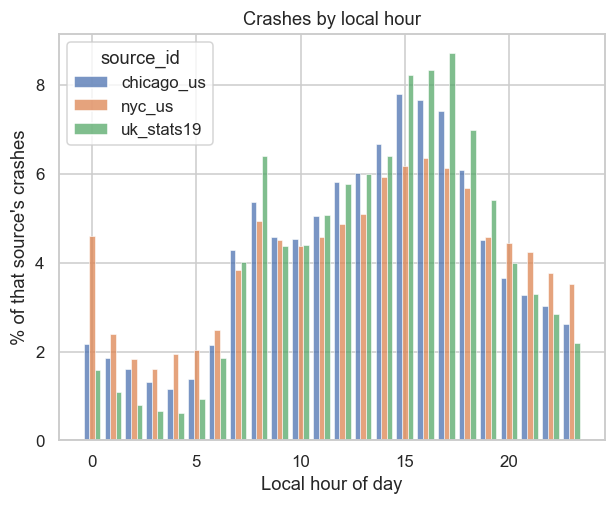

In [3]:
# Share of each source's crashes per local hour. Percent within each
# source (common_norm=False), so the three volumes are comparable.
ax = sns.histplot(data=df, x="local_hour", hue="source_id", stat="percent",
                  common_norm=False, multiple="dodge", discrete=True, shrink=0.8)
ax.set(xlabel="Local hour of day", ylabel="% of that source's crashes",
       title="Crashes by local hour")
plt.show()

### 2.2 Day of week

Crashes per weekday, per source, from **local** time.
`crash_date_key` (and therefore `dim_date.day_of_week`) is the UTC
date, which moves evening crashes in Chicago and NYC to the next day,
so it is not used for weekday analysis.

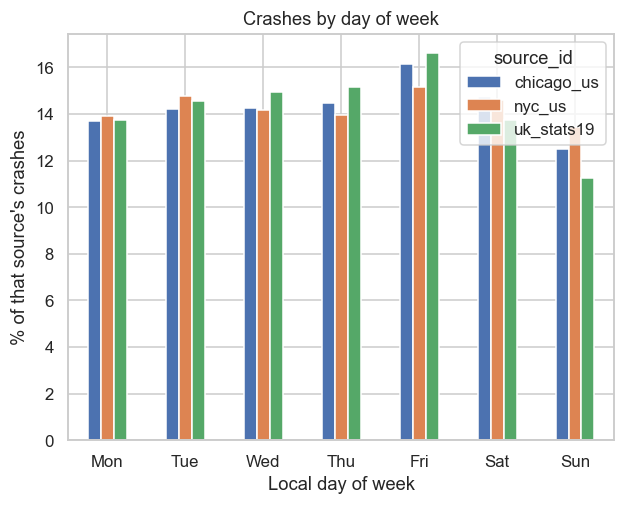

source_id,chicago_us,nyc_us,uk_stats19
Mon,13.7,13.9,13.8
Tue,14.2,14.8,14.6
Wed,14.3,14.2,14.9
Thu,14.5,14.0,15.2
Fri,16.1,15.2,16.6
Sat,14.7,14.6,13.7
Sun,12.5,13.4,11.2


In [4]:
dow = (pd.crosstab(df["local_dow"], df["source_id"], normalize="columns") * 100)
dow.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
ax = dow.plot.bar(rot=0)
ax.set(xlabel="Local day of week", ylabel="% of that source's crashes",
       title="Crashes by day of week")
plt.show()
dow.round(1)

### 2.3 Weekday vs weekend

Crashes per weekday/weekend, per source. `is_weekend` is derived from local time,
for the same reason as above. Two of seven days are weekend days
(28.6%), so a share above that means crashes are concentrated on
weekends.

In [5]:
weekend = (df.groupby("source_id")["is_weekend"].mean() * 100).round(1).rename("% on weekend")
weekend.to_frame()

,% on weekend
source_id,
chicago_us,27.2
nyc_us,28.0
uk_stats19,25.0


## 3. Severity

### 3.1 Severity distribution, per source

Counts of `fatal` / `serious` / `minor` / `none` / `unknown` per source.

**Structural gap to annotate:** NYC cannot produce `serious` at all —
the source has no categorical severity field, only counts. The bar
for NYC's `serious` will be zero or absent by construction, not
because NYC has no serious-injury crashes. This must be annotated in
the chart caption.

In [6]:
sev_order = ["fatal", "serious", "minor", "none", "unknown"]
counts = pd.crosstab(df["severity"], df["source_id"]).reindex(sev_order).fillna(0).astype(int)
counts  # NYC 'serious' is 0 by construction: NYC has no categorical severity field

source_id,chicago_us,nyc_us,uk_stats19
severity,,,
fatal,1141,50,7551
serious,17672,0,116794
minor,140103,9139,389387
none,935096,11348,0
unknown,2383,0,0


### 3.2 Severity share by source

Normalized severity distribution (proportions, not counts), so
sources with vastly different volumes (Chicago ~1.1M, UK ~514K,
NYC a 90-day window) can be compared on shape rather
than absolute count. Still subject to the NYC `serious` gap above.

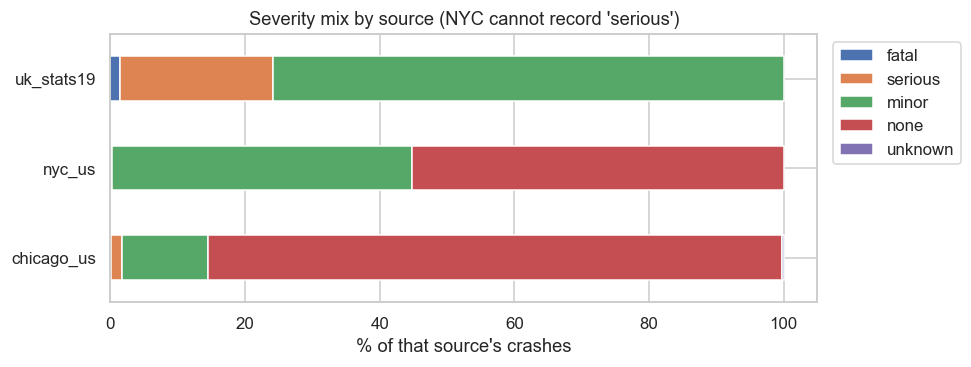

severity,fatal,serious,minor,none,unknown
source_id,,,,,
chicago_us,0.10,1.61,12.78,85.29,0.22
nyc_us,0.24,0.00,44.50,55.26,0.00
uk_stats19,1.47,22.73,75.80,0.00,0.00


In [7]:
share = pd.crosstab(df["source_id"], df["severity"], normalize="index")[
    [c for c in sev_order if c in df["severity"].unique()]] * 100
ax = share.plot.barh(stacked=True, figsize=(9, 3.5))
ax.set(xlabel="% of that source's crashes", ylabel="",
       title="Severity mix by source (NYC cannot record 'serious')")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()
share.round(2)

### 3.3 Injury and fatality counts

Distribution of `num_injured_total` and `num_killed` per source.

**Structural gap to annotate:** `num_killed` is null for `uk_stats19`
(STATS19 casualty detail lives in a separate table not ingested). The
UK box/violin will be absent — annotate this. For NYC, `num_killed`
comes from summing the pedestrian/cyclist/motorist components, not
the (88% null) aggregate field — this is documented in `nyc.yaml`.

In [8]:
# Most crashes have 0 deaths, so a box plot collapses to a line. Report
# the share of crashes with at least one death/injury instead.
# num_killed is null for uk_stats19 (structural gap), so UK shows NaN.
harm = df.groupby("source_id").agg(
    crashes=("crash_id", "size"),
    pct_with_injury=("num_injured_total", lambda s: (s > 0).mean() * 100),
    mean_injured=("num_injured_total", "mean"),
    pct_with_death=("num_killed", lambda s: (s > 0).mean() * 100 if s.notna().any() else float("nan")),
)
harm.round(3)

,crashes,pct_with_injury,mean_injured,pct_with_death
source_id,,,,
chicago_us,1096395,14.526,0.201,0.104
nyc_us,20537,44.554,0.608,0.243
uk_stats19,513732,100.000,1.271,NaN


## 4. Cross-source comparisons

### 4.1 Fatal crash rate by source, coordinates-only subset

Fatal-crash percentage per source, restricted to
`has_valid_coordinates = TRUE`. Using the coordinates subset is
necessary for any follow-on mapping or clustering, and keeps this
number comparable to the spatial analysis later.

**Caveat to state in the caption:** reporting thresholds and coverage
differ by source, so this compares *rates within each source's own
universe*, not a common population.

In [9]:
df_valid = df[df["has_valid_coordinates"]]
fatal_rate = (df_valid.groupby("source_id")["severity"]
              .apply(lambda s: (s == "fatal").mean() * 100)
              .round(3).rename("% fatal (valid coordinates only)"))
fatal_rate.to_frame()

,% fatal (valid coordinates only)
source_id,
chicago_us,0.104
nyc_us,0.231
uk_stats19,1.470


### 4.2 Where cross-source comparison is NOT valid

This cell is a checklist, not an analysis. It documents the fields a
naive cross-source comparison would misinterpret, and the sources
each one is restricted to. It exists so a reader of this notebook
sees the constraint, not just a claim in the writeup.

| Field | Valid sources | Invalid sources | Reason |
|---|---|---|---|
| `crash_type` | chicago_us | nyc_us, uk_stats19 | Neither source classifies crashes by physical type |
| `primary_cause` | chicago_us, nyc_us | uk_stats19 | STATS19 contributory factors live in a separate table |
| `weather_condition` | chicago_us, uk_stats19 | nyc_us | Not collected by NYC |
| `lighting_condition` | chicago_us, uk_stats19 | nyc_us | Not collected by NYC |
| `posted_speed_limit_mph` | chicago_us, uk_stats19 | nyc_us | Not collected by NYC |
| `num_killed` | chicago_us, nyc_us | uk_stats19 | STATS19 casualty detail separate |
| `hit_and_run` | chicago_us | nyc_us, uk_stats19 | Defaults to false elsewhere (no source signal) |
| `severity = 'serious'` | chicago_us, uk_stats19 | nyc_us | NYC has no categorical severity field |
| `police_notified_timestamp_utc` | chicago_us | nyc_us, uk_stats19 | No equivalent field in either source |
| `city` | chicago_us, nyc_us | uk_stats19 | UK is a national (GB-wide) dataset |

**Finding.**

*Coverage.* Chicago and the UK have steady annual volumes: about
108,000–119,000 crashes a year for Chicago (2018–2025) and 101,000–106,000
for the UK (2021–2025). Chicago's early years ramp up from 2 rows (2013)
to 83,765 (2017), matching the district-by-district rollout found in
profiling, so Chicago trends should start in 2018. Chicago's dip to
92,075 in 2020 coincides with the pandemic-era drop in traffic. 2026 is a
partial year, and NYC covers only its 90-day window.

*Timing is shared across all three cities.* Crashes are lowest overnight,
rise to a morning peak at 8:00, and are highest in the afternoon:
Chicago peaks at 15:00 (7.8% of its crashes), the UK at 17:00 (8.7%),
and NYC more gently at 16:00 (6.4%), with relatively more late-night
crashes. Friday is the busiest day in every source (15.2–16.6%) and
Sunday the quietest, and every source's weekend share is below the 28.6%
an even spread would give (UK 25.0%, Chicago 27.2%, NYC 28.0%). Crashes
follow weekday travel, not weekend leisure, in all three places. NYC's
4.6% at 00:00 is more than double its 01:00 share and likely reflects
times recorded as midnight when unknown, so it should not be read as a
real midnight peak.

*Severity rates mostly measure what each source records.* The raw fatal
shares (UK 1.47%, NYC 0.24%, Chicago 0.10%) cannot be compared directly:
STATS19 only records collisions with an injury (100% of UK rows have a
casualty and none are `none`), while 85.3% of Chicago's crashes involve
no injury. Restricting to injury crashes narrows the gap to UK 1.47%,
Chicago 0.72% and NYC 0.54% fatal. Even this is not like-for-like:
Chicago counts "reported, not evident" injuries as minor, and NYC cannot
record `serious` at all.

*For the project problem:* the integrated dataset supports direct
cross-city comparison of *when* crashes happen, because timing is
recorded consistently. Severity comparisons are only valid after
normalizing to a common inclusion rule (injury crashes only), which is
exactly why the pipeline documents each source's structural gaps.

## 5. Data quality signals surfaced by the curated layer

### 5.1 Coordinate coverage

Percentage of rows with `has_valid_coordinates = TRUE`, per source.
From profiling (documented in `docs/data_dictionary.md`): Chicago
0.78% missing, NYC 2.3% sentinel `(0,0)`, UK ~0.01% missing. The point
of this cell is to confirm that what the notebook sees matches what
profiling found.

In [10]:
coverage = (df.groupby("source_id")["has_valid_coordinates"].mean() * 100).round(2)
coverage.rename("% rows with valid coordinates").to_frame()

,% rows with valid coordinates
source_id,
chicago_us,99.22
nyc_us,96.95
uk_stats19,99.99


### 5.2 Data-quality outcomes from `dq_run_log`

The `dq_run_log` table records which checks passed/failed per batch.
This cell queries it to show whether the batches currently in the
curated layer passed all checks.

Requires the Docker stack to be running. Credentials are read from
the project's `.env` file (never hard-coded); the database is reached
on `localhost` through the port Docker Compose publishes.

In [11]:
import os
import psycopg2

def read_env(path=Path("../.env")) -> dict:
    """Minimal .env reader so credentials stay out of the notebook."""
    env = {}
    if path.exists():
        for line in path.read_text(encoding="utf-8").splitlines():
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                k, v = line.split("=", 1)
                env[k.strip()] = v.strip().strip('"').strip("'")
    return env

env = {**read_env(), **os.environ}
try:
    conn = psycopg2.connect(
        host=env.get("PIPELINE_POSTGRES_HOST", "localhost"),
        port=env.get("POSTGRES_PORT", "5432"),
        dbname=env.get("POSTGRES_DB", "crash_pipeline"),
        user=env["POSTGRES_USER"],
        password=env["POSTGRES_PASSWORD"],
    )
    # Query through the psycopg2 cursor rather than pd.read_sql, which only
    # officially supports SQLAlchemy connections and warns on a raw DBAPI one.
    # This avoids adding SQLAlchemy as a dependency just for one query.
    with conn, conn.cursor() as cur:
        cur.execute(
            "SELECT source_id, check_name, status, rows_checked, rows_failed, run_timestamp "
            "FROM dq_run_log ORDER BY run_timestamp DESC LIMIT 24")
        dq = pd.DataFrame(cur.fetchall(), columns=[d[0] for d in cur.description])
    conn.close()
    display(dq)
except Exception as e:  # keep the rest of the notebook usable without the DB
    print(f"Could not query dq_run_log ({type(e).__name__}: {e}). Is the Docker stack running?")

,source_id,check_name,status,rows_checked,rows_failed,run_timestamp
0,chicago_us,row_count_check,pass,1096581,0,2026-10-06 13:42:42.071359+00:00
1,chicago_us,referential_check,pass,1096581,0,2026-10-06 13:42:42.025520+00:00
2,chicago_us,date_logic_check,warn,1096581,1,2026-10-06 13:42:41.981136+00:00
3,chicago_us,range_check,warn,1096581,8320,2026-10-06 13:40:18.617039+00:00
4,chicago_us,accepted_values_check,pass,1096581,0,2026-10-06 13:40:16.182826+00:00
5,chicago_us,uniqueness_check,pass,1096581,0,2026-10-06 13:40:16.134853+00:00
6,chicago_us,nullability_check,pass,1096581,0,2026-10-06 13:40:14.333737+00:00
7,chicago_us,schema_check,pass,1096581,0,2026-10-06 13:40:14.230337+00:00
8,uk_stats19,row_count_check,pass,513801,0,2026-10-06 13:34:04.349603+00:00
9,uk_stats19,referential_check,pass,513801,0,2026-10-06 13:34:04.321344+00:00


## 6. Notes for anyone extending this notebook

1. **Do not read the raw layer.** The curated Parquet layer already has
   the canonical schema, harmonized values, and cleared sentinels.
   Reading `data/raw/` re-implements logic the pipeline exists to
   centralize and will produce numbers that disagree with the
   Postgres table.

2. **Always convert to local time before plotting hourly patterns.**
   `crash_timestamp_utc` is UTC; a UTC-only hour histogram puts each
   city's morning peak at a different clock position and makes the
   cross-city comparison meaningless. The source's local timezone is
   in the `source_local_timezone` column (also on `dim_source`). The
   same applies to weekdays: `crash_date_key` is the UTC date.

3. **Annotate structural nulls, do not silently drop them.** If a
   chart excludes UK rows because `num_killed` is null, the caption
   should say so. A reader who does not know the gap will interpret
   the absence of a bar as a zero.

4. **Use `has_valid_coordinates` for any spatial filtering.** Do not
   filter on `latitude IS NOT NULL AND longitude IS NOT NULL`
   directly; the sentinel `(0,0)` rows would pass that check and place
   crashes in the Gulf of Guinea.

5. **Report per-source, not just aggregate.** A single count across
   all sources hides the fact that they cover different geographies,
   different legal definitions of severity, and different time spans.